

## Dataset Description

This dataset contains information about medical appointments in Brazil. It has about 100,000 appointment records. The main goal of the dataset is to study whether patients attend their appointments or miss them.

Each row represents one medical appointment and includes information about the patient and the appointment.

The dataset contains the following columns:

- PatientId: Patient identification number.
- AppointmentID: Appointment identification number.
- Gender: Patient gender.
- ScheduledDay: The day the appointment was booked.
- AppointmentDay: The day of the appointment.
- Age: Patient age.
- Neighbourhood: Hospital location.
- Scholarship: Whether the patient is enrolled in a welfare program.
- Hipertension: Whether the patient has hypertension.
- Diabetes: Whether the patient has diabetes.
- Alcoholism: Whether the patient has alcoholism.
- Handcap: Whether the patient has a disability.
- SMS_received: Whether the patient received an SMS reminder.
- No-show: Whether the patient missed the appointment. "Yes" means the patient did not attend, and  "No" means the patient attended.

- This dataset has only one table, so there are no relationships between multiple tables.

### Question(s) for Analysis

The main variable in this analysis is **No-show**, which indicates whether a patient attended the appointment or not.

The following questions will be explored:

1. Is there a relationship between receiving an SMS reminder and whether patients attend their appointments?
2. Is there a relationship between patient age and appointment attendance?
3. Is there a relationship between enrollment in the scholarship program and whether patients attend their appointments?

In [99]:
import pandas as pd
import matplotlib.pyplot as plot

%matplotlib inline


In [100]:
df=pd.read_csv('Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv')
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [48]:
df.shape

(110527, 14)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [50]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [51]:
df.duplicated().sum()

0

In [52]:
df.query("Age == -1")

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


The Age column contains one record with an invalid value of -1. This is an unusual value because age cannot be negative.


### Cleaning Invalid Age

I found an invalid value in the `Age` column, which was `-1`. This value does not make sense because age cannot be negative. Since there was only one record with this invalid value and we do not know the patient's actual age, I decided to remove this record.

In [53]:
df.drop(99832, inplace=True)

In [54]:
df.query("Age == -1")

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show



### Convert Date Columns

We found that the `ScheduledDay` and `AppointmentDay` columns were stored as `object` data types. Since these columns contain dates, we converted them to `datetime` format to make the analysis easier and allow date-based operations.

In [55]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  object             
 3   ScheduledDay    110526 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110526 non-null  datetime64[ns, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  object             
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No-show       

In [57]:
df['Handcap'].unique()

array([0, 1, 2, 3, 4])

In [58]:
df['Handcap'].value_counts()

0    108285
1      2042
2       183
3        13
4         3
Name: Handcap, dtype: int64

In [59]:
df.query("Handcap > 1")

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
946,7.282582e+13,5582483,M,2016-04-14 09:26:08+00:00,2016-04-29 00:00:00+00:00,94,BELA VISTA,0,1,1,0,2,1,No
1665,1.242919e+13,5525497,M,2016-03-30 09:16:41+00:00,2016-04-29 00:00:00+00:00,64,SANTA MARTHA,0,1,0,1,2,1,No
1666,1.242919e+13,5525498,M,2016-03-30 09:16:41+00:00,2016-04-29 00:00:00+00:00,64,SANTA MARTHA,0,1,0,1,2,0,No
2071,1.242919e+13,5640120,M,2016-04-29 10:08:48+00:00,2016-04-29 00:00:00+00:00,64,SANTA MARTHA,0,1,0,1,2,0,No
2091,1.491829e+13,5638626,F,2016-04-29 08:13:59+00:00,2016-04-29 00:00:00+00:00,11,ANDORINHAS,0,0,0,0,2,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108376,2.387212e+14,5756931,F,2016-06-01 08:48:28+00:00,2016-06-07 00:00:00+00:00,44,ROMÃO,0,1,1,0,2,1,No
109484,3.589495e+14,5752442,M,2016-05-31 11:45:57+00:00,2016-06-02 00:00:00+00:00,64,DA PENHA,0,1,1,0,2,0,No
109733,5.662976e+14,5772744,F,2016-06-03 16:11:00+00:00,2016-06-07 00:00:00+00:00,34,JUCUTUQUARA,0,0,0,0,2,1,No
109975,4.522185e+13,5766970,M,2016-06-02 16:07:36+00:00,2016-06-06 00:00:00+00:00,39,PRAIA DO SUÁ,1,0,0,0,2,1,No


The data dictionary says that Handcap should be True or False, but our data contains 2, 3, and 4. There are 199 records with values greater than 1.

### Cleaning Handcap

The `Handcap` column contains values from 0 to 4. To simplify this variable into a binary indicator, I converted `0` to `0` and all values greater than `0` to `1`. This preserves all records while treating any positive value as indicating a disability.


In [60]:
df['Handcap'] = (df['Handcap'] > 0).astype(int)

In [61]:
df['Handcap'].unique()

array([0, 1])

We ran the code and the result showed only 0 and 1, so the `Handcap` column is now in the correct binary format.

### Change PatientId Data Type

We changed the data type of `PatientId` from `float64` to `int64` because `PatientId` is an identification number and does not need decimal values.

In [62]:
df['PatientId'] = df['PatientId'].astype(int)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  int64              
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  object             
 3   ScheduledDay    110526 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110526 non-null  datetime64[ns, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  object             
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No-show       

In [64]:


df['No-show'].unique()

array(['No', 'Yes'], dtype=object)


### Cleaning No-show

The `No-show` column contains the values `Yes` and `No`. I converted them to `1` and `0` respectively to make the variable easier to analyze, where `1` means the patient did not attend the appointment and `0` means the patient attended.

In [65]:
df['No-show'] = df['No-show'].replace({'Yes': 1, 'No': 0})

In [66]:
df['No-show'].unique()

array([0, 1])

In [67]:
df['Age'].describe()

count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [68]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,1.474934e+14,5.675304e+06,37.089219,0.098266,0.197248,0.071865,0.030400,0.020276,0.321029,0.201934
std,2.560943e+14,7.129544e+04,23.110026,0.297676,0.397923,0.258266,0.171686,0.140943,0.466874,0.401445
min,3.921700e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172536e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680572e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  int64              
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  object             
 3   ScheduledDay    110526 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110526 non-null  datetime64[ns, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  object             
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No-show       

In [70]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [71]:
df['Neighbourhood'].unique()


array(['JARDIM DA PENHA', 'MATA DA PRAIA', 'PONTAL DE CAMBURI',
       'REPÚBLICA', 'GOIABEIRAS', 'ANDORINHAS', 'CONQUISTA',
       'NOVA PALESTINA', 'DA PENHA', 'TABUAZEIRO', 'BENTO FERREIRA',
       'SÃO PEDRO', 'SANTA MARTHA', 'SÃO CRISTÓVÃO', 'MARUÍPE',
       'GRANDE VITÓRIA', 'SÃO BENEDITO', 'ILHA DAS CAIEIRAS',
       'SANTO ANDRÉ', 'SOLON BORGES', 'BONFIM', 'JARDIM CAMBURI',
       'MARIA ORTIZ', 'JABOUR', 'ANTÔNIO HONÓRIO', 'RESISTÊNCIA',
       'ILHA DE SANTA MARIA', 'JUCUTUQUARA', 'MONTE BELO',
       'MÁRIO CYPRESTE', 'SANTO ANTÔNIO', 'BELA VISTA', 'PRAIA DO SUÁ',
       'SANTA HELENA', 'ITARARÉ', 'INHANGUETÁ', 'UNIVERSITÁRIO',
       'SÃO JOSÉ', 'REDENÇÃO', 'SANTA CLARA', 'CENTRO', 'PARQUE MOSCOSO',
       'DO MOSCOSO', 'SANTOS DUMONT', 'CARATOÍRA', 'ARIOVALDO FAVALESSA',
       'ILHA DO FRADE', 'GURIGICA', 'JOANA D´ARC', 'CONSOLAÇÃO',
       'PRAIA DO CANTO', 'BOA VISTA', 'MORADA DE CAMBURI', 'SANTA LUÍZA',
       'SANTA LÚCIA', 'BARRO VERMELHO', 'ESTRELINHA', 'FORTE SÃO 

In [72]:
df.duplicated().sum()

0


### Research Question 1: Is there a relationship between receiving an SMS reminder and whether patients attend their appointments?


In [73]:
df['No-show'].value_counts()


0    88207
1    22319
Name: No-show, dtype: int64

In [74]:
df["SMS_received"].value_counts()

0    75044
1    35482
Name: SMS_received, dtype: int64

In [75]:
df.groupby('SMS_received')['No-show'].value_counts()

SMS_received  No-show
0             0          62509
              1          12535
1             0          25698
              1           9784
Name: No-show, dtype: int64

In [76]:
sms_no_show = df.groupby('SMS_received')['No-show'].value_counts(normalize=True)
sms_no_show

SMS_received  No-show
0             0          0.832965
              1          0.167035
1             0          0.724255
              1          0.275745
Name: No-show, dtype: float64

We found that 16.7% of patients who did not receive an SMS reminder did not attend their appointments, compared with 27.6% of patients who received an SMS reminder.

<AxesSubplot: xlabel='SMS_received,No-show'>

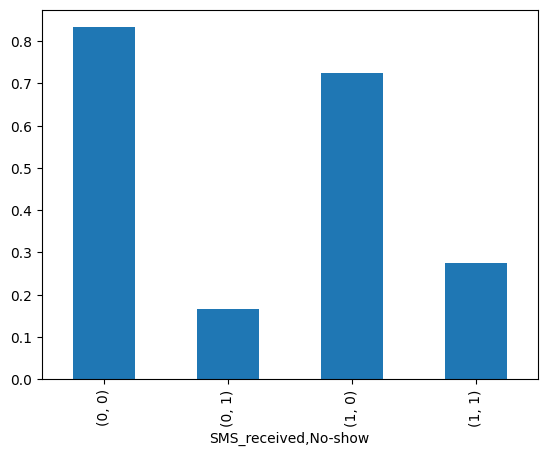

In [79]:
sms_no_show.plot(kind='bar')

The bar chart shows four different combinations of SMS reminders and appointment attendance.

- 00: Attended the appointment and did not receive an SMS.
- 01: Did not attend the appointment and did not receive an SMS.
- 10: Attended the appointment and received an SMS.
- 11: Did not attend the appointment and received an SMS.

The chart shows that the no-show percentage was higher among patients who received an SMS reminder. The `(1,1)` bar (27.6%) is higher than the `(0,1)` bar (16.7%), indicating a higher no-show rate among patients who received an SMS reminder.


### Research Question 2: Is there a relationship between patient age and appointment attendance?


In [83]:
df['Age'].describe()

count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [88]:
df.groupby('No-show')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
No-show,,,,,,,,
0,88207.0,37.790504,23.338645,0.0,18.0,38.0,56.0,115.0
1,22319.0,34.317667,21.965941,0.0,16.0,33.0,51.0,115.0


The median age of patients who attended their appointments was higher than that of patients who did not attend (38 vs. 33 years). The mean age was also higher among patients who attended (37.8 vs. 34.3 years), suggesting that younger patients were more likely to miss their appointments in this dataset.

<AxesSubplot: title={'center': 'Age'}, xlabel='No-show'>

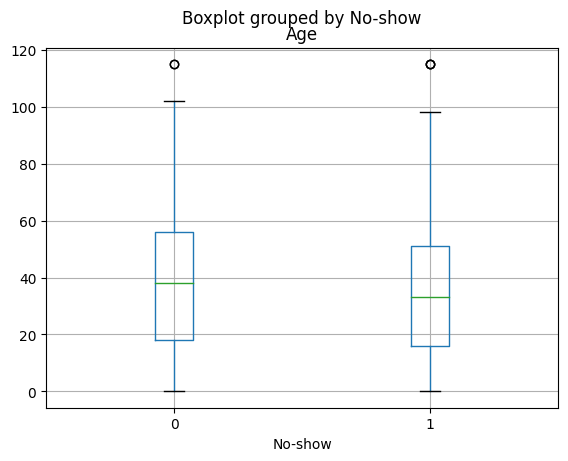

In [90]:
df.boxplot(column='Age', by='No-show')

In the box plot, 0 represents patients who attended their appointments, while 1 represents patients who did not attend. The line inside each box represents the median age, and the box represents the middle 50% of patient ages. Points outside the main range may represent outliers.



### Research Question 3: Is there a relationship between enrollment in the scholarship program and whether patients attend their appointments?


In [91]:
df.Scholarship.value_counts()

0    99665
1    10861
Name: Scholarship, dtype: int64

In [93]:
df.groupby('Scholarship')['No-show'].value_counts()

Scholarship  No-show
0            0          79924
             1          19741
1            0           8283
             1           2578
Name: No-show, dtype: int64

In [94]:
df.groupby('Scholarship')['No-show'].value_counts(normalize=True)


Scholarship  No-show
0            0          0.801926
             1          0.198074
1            0          0.762637
             1          0.237363
Name: No-show, dtype: float64

The results show that patients enrolled in the scholarship program had a higher no-show rate compared with patients who were not enrolled (23.7% vs. 19.8%).

In [95]:
sc = df.groupby('Scholarship')['No-show'].value_counts(normalize=True)

<AxesSubplot: xlabel='Scholarship,No-show'>

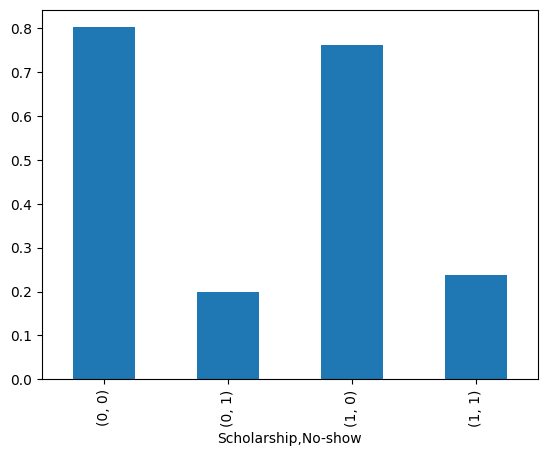

In [96]:
sc.plot(kind='bar')

The bar chart shows four different combinations of scholarship enrollment and appointment attendance.

* `00`: Not enrolled in the scholarship program and attended the appointment.
* `01`: Not enrolled in the scholarship program and did not attend the appointment.
* `10`: Enrolled in the scholarship program and attended the appointment.
* `11`: Enrolled in the scholarship program and did not attend the appointment.

The first digit represents `Scholarship`, while the second digit represents `No-show`.

The chart shows that the no-show rate was higher among patients enrolled in the scholarship program. The `11` bar (23.7%) is higher than the `01` bar (19.8%), indicating a higher no-show rate among scholarship-enrolled patients in this dataset.


### Conclusions
The analysis explored three factors that may be related to appointment attendance: SMS reminders, patient age, and enrollment in the scholarship program.

Patients who received an SMS reminder had a higher no-show rate than patients who did not receive one (27.6% vs. 16.7%). Patients who attended their appointments also had a higher median age than patients who did not attend (38 vs. 33 years). In addition, patients enrolled in the scholarship program had a higher no-show rate than patients who were not enrolled (23.7% vs. 19.8%).

These findings show differences between the groups in this dataset, but they do not prove that SMS reminders, age, or scholarship enrollment caused patients to miss their appointments.

### Limitation
One limitation of this analysis is that it only explores relationships between individual variables and appointment attendance. Other factors may also affect whether a patient attends an appointment, and no statistical tests were performed to determine whether the observed differences are statistically significant. Further analysis could examine additional variables and use statistical tests to better understand these relationships.

In [101]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 407609 bytes to Investigate_a_Dataset.html
